# Multimodal Retrieval-Augmented Generation (RAG) with Document Retrieval (ColPali) and Vision Language Models (VLMs)

_Authored by: [Sergio Paniego](https://github.com/sergiopaniego)_



**🚨 WARNING**: This notebook is resource-intensive and requires substantial computational power. If you're running this in Colab, it will utilize an A100 GPU.

In this notebook, we demonstrate how to build a **Multimodal Retrieval-Augmented Generation (RAG)** system by combining the [**ColPali**](https://huggingface.co/blog/manu/colpali) retriever for document retrieval with the [**Qwen2-VL**](https://qwenlm.github.io/blog/qwen2-vl/) Vision Language Model (VLM). Together, these models form a powerful RAG system capable of enhancing query responses with both text-based documents and visual data.

Instead of relying on a complex document processor pipeline that extracts data through OCR, we will leverage a Document Retrieval Model to efficiently retrieve the relevant documents based on a specific user query.

I also recommend checking out and starring the [smol-vision](https://github.com/merveenoyan/smol-vision) repository, which inspired this notebook—especially [this notebook](https://github.com/merveenoyan/smol-vision/blob/main/ColPali_%2B_Qwen2_VL.ipynb). For an introduction to RAG, you can check [this other cookbook](rag_zephyr_langchain)!





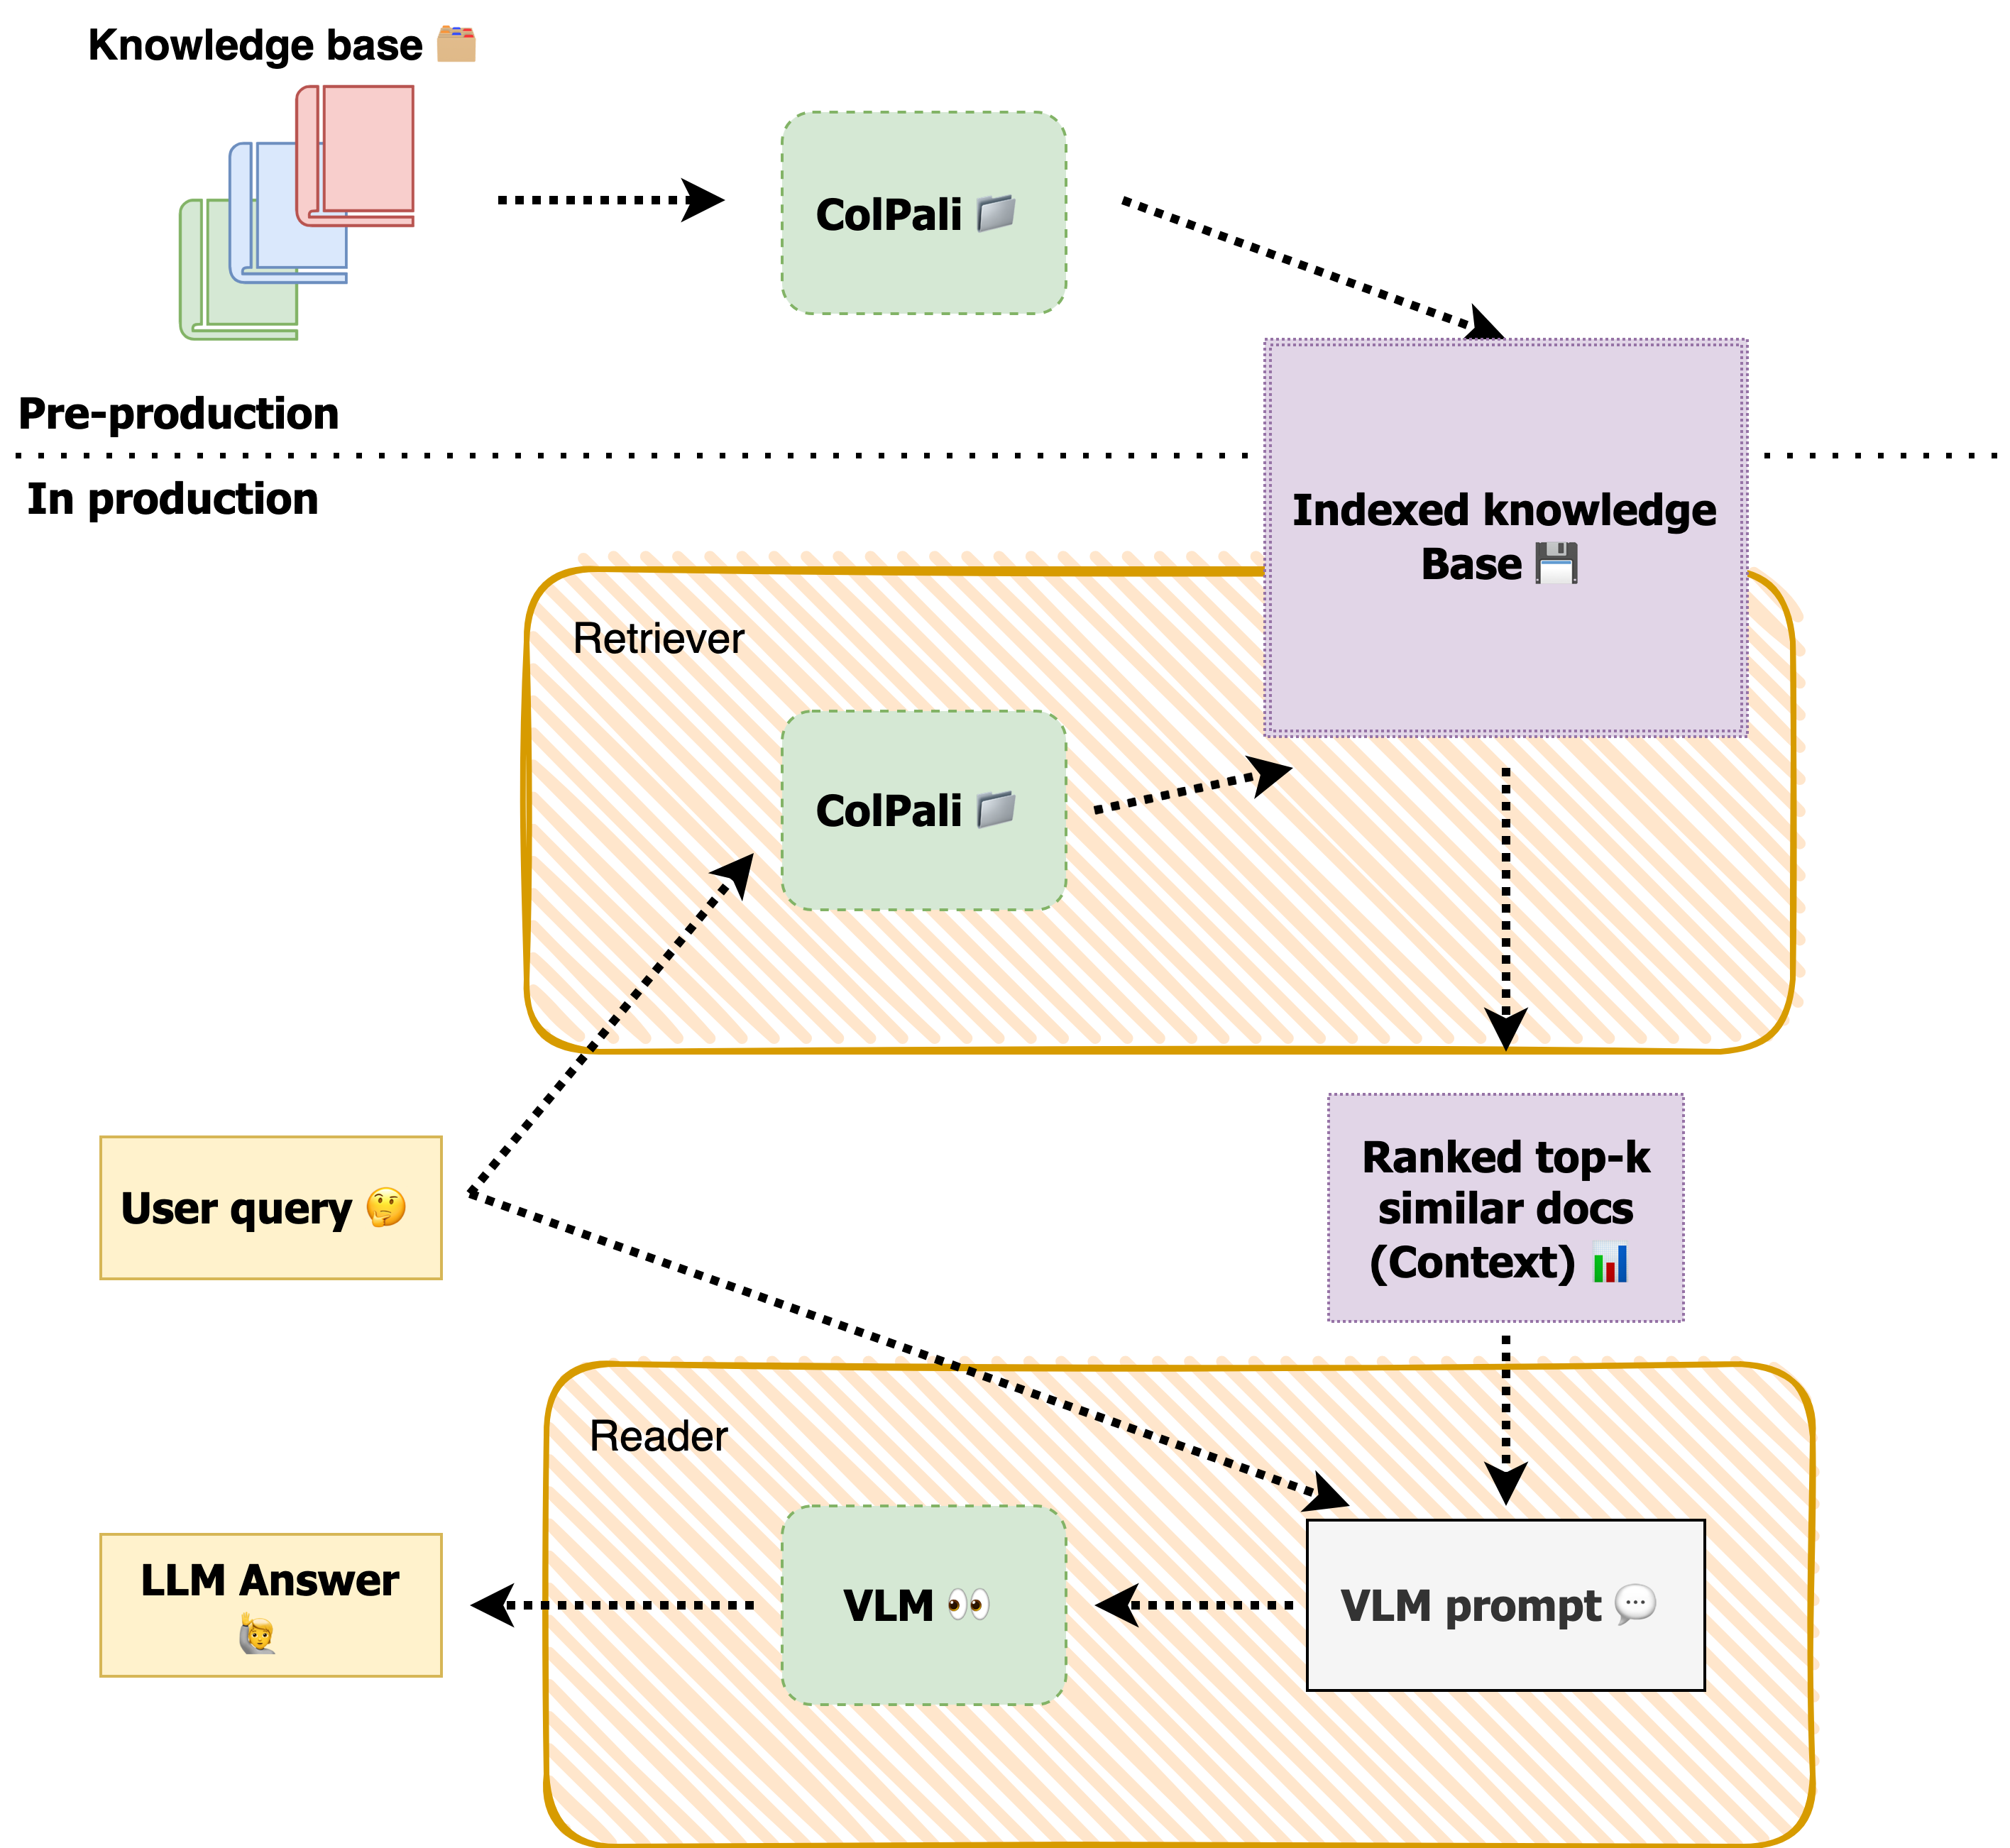

This diagram is inspired by [Aymeric Roucher's](https://huggingface.co/m-ric) work in the [Advanced RAG](https://huggingface.co/learn/cookbook/advanced_rag) or [RAG Evaluation](https://huggingface.co/learn/cookbook/rag_evaluation) recipes.


## 1. Install dependencies

Let’s kick off by installing the essential libraries for our project! 🚀



In [1]:
!pip install -U -q pip
!pip install -U -q byaldi pdf2image qwen-vl-utils transformers langchain
# Tested with byaldi==0.0.4, pdf2image==1.17.0, qwen-vl-utils==0.0.8, transformers==4.45.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.0/33.0 MB 129.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


We will also install **poppler-utils** to facilitate PDF manipulation. This utility provides essential tools for working with PDF files, ensuring we can efficiently handle any document-related tasks in our project.


In [2]:
!sudo apt-get install -y poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 186 kB of archives.
After this operation, 696 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.5 [186 kB]
Fetched 186 kB in 1s (185 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package poppler-utils.
(Reading database ... 123633 

## 2. Load Dataset 📁

For this notebook, we will use charts and maps from [Our World in Data](https://ourworldindata.org/), a valuable resource offering open access to a wide range of data and visualizations. Specifically, we will focus on the [life expectancy data](https://ourworldindata.org/life-expectancy).

To facilitate easy access, we've curated a small subset of this data in the following [dataset](https://huggingface.co/datasets/sergiopaniego/ourworldindata_example).

While we have selected a few examples from this source for demonstration purposes, in a real-world scenario, you could work with a much larger collection of visual data to further enhance your model's capabilities.

**Citation:**

```
Saloni Dattani, Lucas Rodés-Guirao, Hannah Ritchie, Esteban Ortiz-Ospina and Max Roser (2023) - “Life Expectancy” Published online at OurWorldinData.org. Retrieved from: 'https://ourworldindata.org/life-expectancy' [Online Resource]
```


In [3]:
from datasets import load_dataset

dataset = load_dataset("sergiopaniego/ourworldindata_example", split='train')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/328 [00:00<?, ?B/s]

(…)-standardized-deaths-from-all-causes.png:   0%|          | 0.00/932k [00:00<?, ?B/s]

annual-death-rate-by-age-group.png:   0%|          | 0.00/505k [00:00<?, ?B/s]

(…)rates-in-different-age-groups-by-sex.png:   0%|          | 0.00/483k [00:00<?, ?B/s]

...

(…)at-year-among-females-of-a-given-age.png:   0%|          | 0.00/835k [00:00<?, ?B/s]

(…)that-year-among-males-of-a-given-age.png:   0%|          | 0.00/876k [00:00<?, ?B/s]

(…)die-in-the-first-year-of-life-by-sex.png:   0%|          | 0.00/490k [00:00<?, ?B/s]

(…)ng-life-expectancy-at-different-ages.png:   0%|          | 0.00/547k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/13 [00:00<?, ? examples/s]

After downloading the visual data, we will save it locally to enable the RAG (Retrieval-Augmented Generation) system to index the files later. This step is crucial, as it allows the document retrieval model (ColQwen2) to efficiently process and manipulate the visual content. Additionally, we reduce the image size to **448x448** to further minimize memory consumption and ensure faster processing, which is important for optimizing performance in large-scale operations.



In [4]:
import os
from PIL import Image

def save_images_to_local(dataset, output_folder="data/"):
    os.makedirs(output_folder, exist_ok=True)

    for image_id, image_data in enumerate(dataset):
        image = image_data['image']

        if isinstance(image, str):
            image = Image.open(image)

        image = image.resize((448, 448))

        output_path = os.path.join(output_folder, f"image_{image_id}.png")

        image.save(output_path, format='PNG')

        print(f"Image saved in: {output_path}")

save_images_to_local(dataset)

Image saved in: data/image_0.png
Image saved in: data/image_1.png
Image saved in: data/image_2.png
Image saved in: data/image_3.png
Image saved in: data/image_4.png
Image saved in: data/image_5.png
Image saved in: data/image_6.png
Image saved in: data/image_7.png
Image saved in: data/image_8.png
Image saved in: data/image_9.png
Image saved in: data/image_10.png
Image saved in: data/image_11.png
Image saved in: data/image_12.png


After downloading the assembly instructions, we will convert the PDFs into images. This step is crucial, as it allows the document retrieval model (ColPali) to process and manipulate the visual content effectively.


In [5]:
import os
from PIL import Image

def load_png_images(image_folder):
    png_files = [f for f in os.listdir(image_folder) if f.endswith('.png')]
    all_images = {}

    for image_id, png_file in enumerate(png_files):
        image_path = os.path.join(image_folder, png_file)
        image = Image.open(image_path)
        all_images[image_id] = image

    return all_images

all_images = load_png_images("/content/data/")

Let’s visualize a sample assembly guide to get a sense of how these instructions are presented! This will help us understand the format and layout of the content we’ll be working with. 👀


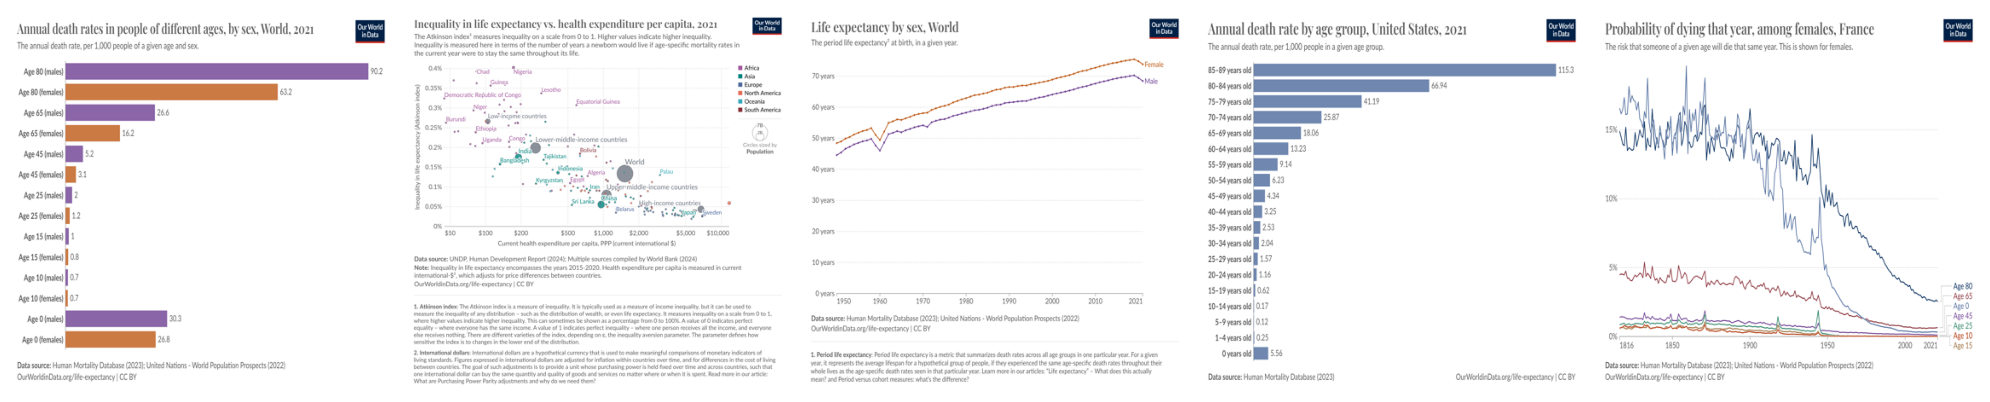

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 15))

for i, ax in enumerate(axes.flat):
    img = all_images[i]
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Initialize the ColPali Multimodal Document Retrieval Model 🤖


Now that our dataset is ready, we will initialize the Document Retrieval Model, which will be responsible for extracting relevant information from the raw images and providing us with the appropriate documents based on our queries.

By utilizing this model, we can significantly enhance our conversational capabilities.

For this task, we will use **[Byaldi](https://github.com/AnswerDotAI/byaldi)**. The developers describe the library as follows: _"Byaldi is RAGatouille's mini sister project. It is a simple wrapper around the ColPali repository to make it easy to use late-interaction multi-modal models such as ColPALI with a familiar API."_

In this project, we will specifically focus on **ColPali**.

![ColPali architecture](https://github.com/illuin-tech/colpali/blob/main/assets/colpali_architecture.webp?raw=true)

Additionally, you can explore **[ViDore (The Visual Document Retrieval Benchmark)](https://huggingface.co/spaces/vidore/vidore-leaderboard)** to see the top-performing retrievers in action.


First, we will load the model from the checkpoint.


In [7]:
from byaldi import RAGMultiModalModel

docs_retrieval_model = RAGMultiModalModel.from_pretrained("vidore/colqwen2-v1.0")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Verbosity is set to 1 (active). Pass verbose=0 to make quieter.


adapter_config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

Next, we can directly index our documents using the document retrieval model by specifying the folder where the PDFs are stored. This will allow the model to process and organize the documents for efficient retrieval based on our queries.


In [8]:
docs_retrieval_model.index(
    input_path="data/",
    index_name="image_index",
    store_collection_with_index=False,
    overwrite=True
)

Indexing file: data/image_2.png
Added page 1 of document 0 to index.
Index exported to .byaldi/image_index
Indexing file: data/image_5.png
Added page 1 of document 1 to index.
Index exported to .byaldi/image_index
Indexing file: data/image_8.png
Added page 1 of document 2 to index.
Index exported to .byaldi/image_index
Indexing file: data/image_1.png
Added page 1 of document 3 to index.
Index exported to .byaldi/image_index
Indexing file: data/image_9.png
Added page 1 of document 4 to index.
Index exported to .byaldi/image_index
Indexing file: data/image_7.png
Added page 1 of document 5 to index.
Index exported to .byaldi/image_index
Indexing file: data/image_3.png
Added page 1 of document 6 to index.
Index exported to .byaldi/image_index
Indexing file: data/image_6.png
Added page 1 of document 7 to index.
Index exported to .byaldi/image_index
Indexing file: data/image_11.png
Added page 1 of document 8 to index.
Index exported to .byaldi/image_index
Indexing file: data/image_4.png
Adde

{0: 'data/image_2.png',
 1: 'data/image_5.png',
 2: 'data/image_8.png',
 3: 'data/image_1.png',
 4: 'data/image_9.png',
 5: 'data/image_7.png',
 6: 'data/image_3.png',
 7: 'data/image_6.png',
 8: 'data/image_11.png',
 9: 'data/image_4.png',
 10: 'data/image_10.png',
 11: 'data/image_0.png',
 12: 'data/image_12.png'}

## 4. Retrieving Documents with the Document Retrieval Model 🤔

Having initialized the document retrieval model, we can now test its capabilities by submitting a user query and examining the relevant documents it retrieves.

The model will return the results, ranked directly by their relevance to the query.

Let’s give it a try!

In [9]:
text_query = "How many people are needed to assemble the Malm?"

results = docs_retrieval_model.search(text_query, k=3)
results

[{'doc_id': 0, 'page_num': 1, 'score': 8.875, 'metadata': {}, 'base64': None},
 {'doc_id': 12, 'page_num': 1, 'score': 8.1875, 'metadata': {}, 'base64': None},
 {'doc_id': 2, 'page_num': 1, 'score': 8.125, 'metadata': {}, 'base64': None}]

Now, let’s examine the specific documents (images) that the model has retrieved. This will allow us to see the visual content that corresponds to our query and understand how the model selects relevant information.


In [22]:
def get_grouped_images(results, all_images):
    grouped_images = []
    doc_ids = [result['doc_id'] for result in results]
    grouped_images = [all_images[doc_id] for doc_id in doc_ids]
    return grouped_images,doc_ids

grouped_images,doc_ids = get_grouped_images(results, all_images)

In [24]:
doc_ids

[0, 12, 2]

Let’s take a closer look at the retrieved documents to understand the information they contain. This examination will help us evaluate the relevance and quality of the retrieved content in relation to our query.


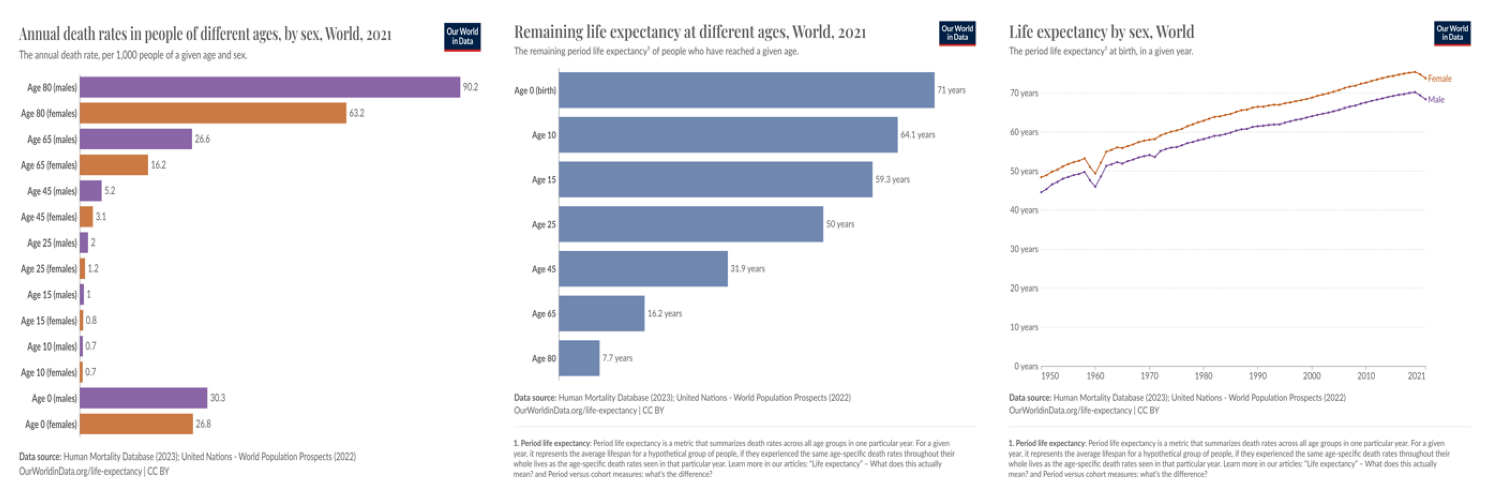

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    img = grouped_images[i]
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

Lagchain Retriver for Byaldi

In [13]:
retriever = docs_retrieval_model.as_langchain_retriever(k=3)

In [14]:
retriever.invoke(text_query)

[{'doc_id': 0, 'page_num': 1, 'score': 8.875, 'metadata': {}, 'base64': None},
 {'doc_id': 12, 'page_num': 1, 'score': 8.1875, 'metadata': {}, 'base64': None},
 {'doc_id': 2, 'page_num': 1, 'score': 8.125, 'metadata': {}, 'base64': None}]

## 5. Initialize the Visual Language Model for Question Answering 🙋

Next, we will initialize the Visual Language Model (VLM) that we will use for question answering. In this case, we’ll be utilizing **[Qwen2_VL](https://huggingface.co/docs/transformers/main/en/model_doc/qwen2_vl)**.

![Qwen2_VL architecture](https://qianwen-res.oss-accelerate-overseas.aliyuncs.com/Qwen2-VL/qwen2_vl.jpg)

You can check the leaderboard for Open VLM to stay updated on the latest advancements [here](https://huggingface.co/spaces/opencompass/open_vlm_leaderboard).

First, we will load the model from the pretrained checkpoint and move it to the GPU for optimal performance. See the model [here](https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct).


In [15]:
!pip install -qU langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00


In [16]:
import os
os.environ["AZURE_OPENAI_API_VERSION"] = "2024-06-01"
os.environ["AZURE_OPENAI_DEPLOYMENT_NAME"] = 'gpt-4o-mini'
os.environ["AZURE_OPENAI_MODEL_VERSION"] = '2024-06-01'

In [17]:
from google.colab import userdata
os.environ["AZURE_OPENAI_API_KEY"] = userdata.get('AZURE_OPENAI_API_KEY')
os.environ["AZURE_OPENAI_ENDPOINT"] = userdata.get('AZURE_OPENAI_ENDPOINT')

In [18]:
from langchain_openai import AzureChatOpenAI
model = AzureChatOpenAI(
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    azure_deployment=os.environ["AZURE_OPENAI_DEPLOYMENT_NAME"],
    openai_api_version=os.environ["AZURE_OPENAI_API_VERSION"],
    model_version=os.environ['AZURE_OPENAI_MODEL_VERSION']
)

## 6. Assembling the VLM Model and Testing the System 🔧

With all components loaded, we can now assemble the system for testing. First, we will create the chat structure by providing the system with the three retrieved images along with the user query. This step can be customized to fit your specific needs, allowing for greater flexibility in how you interact with the model!

In [43]:
def load_image(inputs: dict) -> dict:
    image_path = inputs["image_path"]

    def encode_image(image_path):
        with open(image_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode("utf-8")

    image_base64 = encode_image(image_path)
    return image_base64

In [36]:
image_paths = []
for i in range(len(doc_ids)):
  image_paths.append({'image_path':"/content/data/image_" + str(doc_ids[i])+'.png'})
image_paths

[{'image_path': '/content/data/image_0.png'},
 {'image_path': '/content/data/image_12.png'},
 {'image_path': '/content/data/image_2.png'}]

In [37]:
load_image(image_paths[0])

'...'

In [38]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
import base64

message = HumanMessage(
    content=[
        {"type": "text", "text": text_query},
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{load_image(image_paths[0])}"},
        },
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{load_image(image_paths[1])}"},
        },
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{load_image(image_paths[2])}"},
        },
    ],
)
response = model.invoke([message])
print(response.content)

To assemble the IKEA Malm series, typically 1-2 people are needed. However, the specific number can depend on the size and type of the furniture piece being assembled. For larger items, having two people can make the process easier and faster. Always refer to the instructions provided with the product for the best guidance.


## 7. Assembling It All! 🧑‍🏭️

Now, let’s create a method that encompasses the entire pipeline, allowing us to easily reuse it in future applications.


In [46]:
def answer_with_multimodal_rag(vl_model, docs_retrieval_model, text_query, top_k):
    retriever = docs_retrieval_model.as_langchain_retriever(k=top_k)
    results = retriever.invoke(text_query)
    doc_ids = [result['doc_id'] for result in results]
    image_paths = []
    for i in range(len(doc_ids)):
      image_paths.append({'image_path':"/content/data/image_" + str(doc_ids[i])+'.png'})
    message = HumanMessage(
        content=[
          {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{load_image(image_path)}"}} for image_path in image_paths
            ] + [
          {"type": "text", "text": text_query}
        ],
    )
    response = vl_model.invoke([message])
    return response.content

Let’s take a look at how the complete RAG system operates!


In [47]:
output_text = answer_with_multimodal_rag(
    vl_model=model,
    docs_retrieval_model=docs_retrieval_model,
    text_query="How do I assemble the Micke desk?",
    top_k=3
)
print(output_text)

To assemble the Micke desk, follow these general steps:

### Tools Needed:
- Phillips screwdriver (if screws are included)
- Allen wrench (if applicable, usually included)

### Steps:
1. **Unpack and Organize:**
   - Lay out all the pieces and hardware.
   - Check the instruction manual to ensure you have everything.

2. **Attach the Legs:**
   - Locate the legs and attach them to the underside of the desk top. 
   - Use screws or bolts as indicated in the instructions.

3. **Attach the Drawer:**
   - If the desk has a drawer, slide the drawer rails into the pre-drilled holes on the designated side.
   - Carefully align the drawer and push it in.

4. **Assemble Any Additional Parts:**
   - If there are side panels, shelves, or additional components, attach them according to the instructions.

5. **Secure All Fasteners:**
   - Make sure all screws and bolts are tightened but avoid over-tightening to prevent damage.

6. **Final Adjustments:**
   - Check for stability and make adjustments

🏆 We now have a fully operational RAG pipeline that leverages both a Document Retrieval Model and a Visual Language Model! This powerful combination enables us to generate insightful responses based on user queries and relevant documents.



## 8. Continuing the Journey 🧑‍🎓️

This recipe is just the starting point in exploring the potential of multimodal RAG systems. If you're eager to dive deeper, here are some ideas and resources to guide your next steps:

### 🔍 Explore Further with ColPali:
- [Document Similarity Search with ColPali](https://huggingface.co/blog/fsommers/document-similarity-colpali)
- [ColPali Cookbooks 👀](https://github.com/tonywu71/colpali-cookbooks/tree/main)
- [ColPali Fine-Tuning Query Generator](https://huggingface.co/spaces/davanstrien/ColPali-Query-Generator)
- [Generating a Query Dataset for Fine-Tuning ColPali on a UFO Dataset](https://danielvanstrien.xyz/posts/post-with-code/colpali/2024-09-23-generate_colpali_dataset.html)

### 📖 Additional Reads:
- [Beyond Text: The Rise of Vision-Driven Document Retrieval for RAG](https://blog.vespa.ai/the-rise-of-vision-driven-document-retrieval-for-rag/)
- [Scaling ColPali to Billions of PDFs with Vespa](https://blog.vespa.ai/scaling-colpali-to-billions/)

### 💡 Useful Collections:
- [Multimodal RAG Collection](https://huggingface.co/collections/merve/multimodal-rag-66d97602e781122aae0a5139)

### 📝 The Paper and Original Code:
- [ColPali: Efficient Document Retrieval with Vision Language Models (Paper)](https://arxiv.org/pdf/2407.01449)
- [ColPali: Efficient Document Retrieval with Vision Language Models (Repo)](https://github.com/illuin-tech/colpali)

Feel free to explore these resources as you continue your journey into the world of multimodal retrieval and generation systems!

